In [1]:
import pandas as pd
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
query0126 = pd.read_csv("Queries/New_Query_2026_01_26_12_07pm.csv")
query0126["Win"] = query0126["general_election_result"] == "Won General"
query0126["Win"].value_counts()


Win
False    7748
True     2252
Name: count, dtype: int64

In [3]:
# Select all features except the target
X = query0126.drop(columns=["Win", "general_election_result"])

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Fill any remaining NAs with column mean (for numeric columns)
X = X.dropna(axis=1)
X = X.fillna(X.mean())

y = query0126["Win"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit logistic regression
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00      1566
        True       0.22      1.00      0.36       434

    accuracy                           0.22      2000
   macro avg       0.11      0.50      0.18      2000
weighted avg       0.05      0.22      0.08      2000



/Users/myschne/Desktop/school/Ross/Good Party/GoodParty/.venv-model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/myschne/Desktop/school/Ross/Good Party/GoodParty/.venv-model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/myschne/Desktop/school/Ross/Good Party/GoodParty/.venv-model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

              precision    recall  f1-score   support

       False       0.00      0.00      0.00      1566
        True       0.22      1.00      0.36       434

    accuracy                           0.22      2000
   macro avg       0.11      0.50      0.18      2000
weighted avg       0.05      0.22      0.08      2000



/Users/myschne/Desktop/school/Ross/Good Party/GoodParty/.venv-model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/myschne/Desktop/school/Ross/Good Party/GoodParty/.venv-model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/myschne/Desktop/school/Ross/Good Party/GoodParty/.venv-model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

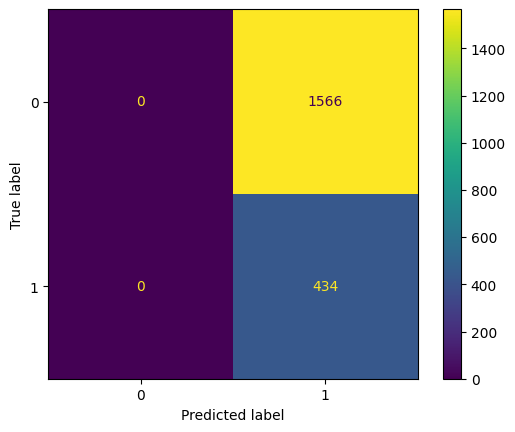

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Show confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


state value counts and Win rate:
state
TX                      1.000000
Oregon                  0.632184
Iowa                    0.615385
Kansas                  0.554054
Idaho                   0.520000
Wisconsin               0.502370
Washington              0.494071
Illinois                0.488506
Ohio                    0.474057
Vermont                 0.470588
Minnesota               0.468927
Massachusetts           0.455556
New Mexico              0.439560
Montana                 0.433333
North Dakota            0.375000
Virginia                0.361446
Utah                    0.350515
Michigan                0.344961
Kentucky                0.326923
New Hampshire           0.317073
Nebraska                0.314286
Missouri                0.306122
South Carolina          0.304762
North Carolina          0.280936
Mississippi             0.280000
South Dakota            0.277778
Alaska                  0.275862
Alabama                 0.274854
District Of Columbia    0.258065
Wyo

/var/folders/4v/55nqzrk56yz5gzf4ld7y124h0000gn/T/ipykernel_28460/95624849.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in query0126.select_dtypes(include='object').columns:
